In [2]:
# Cell 1 — Imports + Config (NO threshold; fixed BAD_FINAL_FAMILIES case)

import os
import re
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import classification_report, accuracy_score
from sklearn.inspection import permutation_importance


# ===================== EDIT THESE =====================
CONSENSUS_CSV = Path("data/vera_dataset_consensus_master.csv")
SAMPLES_DIR   = Path(r"/mnt/mydrive/Datasets/Nithish Dataset/Sorted_Dataset/Files/Ransomware")

CAPE_DIR  = Path(r"/mnt/mydrive/RW_Dataset_Paper/Clustering/RW_Cape_15k")
CAPE_GLOB = "*.json"

OUT_DIR = Path("./outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Use which feature sources?
USE_STATIC_EXE_FEATURES = True
USE_CAPE_FEATURES       = True

# Tokens optional (OFF by default)
USE_CAPE_TOKEN_FEATURES = False

# Training label filters
GOOD_CONSENSUS_TYPES = {"strong_consensus_3", "strong_consensus_2", "majority_vote"}

# IMPORTANT: must match df["Final_Family"] after .str.lower()
BAD_FINAL_FAMILIES   = {"unknown", "conflict", "nan", "-", "singleton", "generic", "null", "none", ""}

# Control size / balance
MIN_FAMILY_SIZE = 50
TOP_N_FAMILIES  = None     # e.g. 20, or None for all

RANDOM_STATE = 42

# -------- Feature Selection Controls --------
DO_FEATURE_SELECTION = True
FS_MAX_FEATURES = 100

FS_DROP_NZV_FREQ = 0.98
FS_DROP_MISSING_FRAC = 0.40

FS_PERM_REPEATS = 3
FS_SCORING = "accuracy"

# Output tag (so files don't overwrite)
RUN_TAG = "all_labels"

print("OUT_DIR:", OUT_DIR.resolve())
print("RUN_TAG:", RUN_TAG)
print("USE_CAPE_TOKEN_FEATURES:", USE_CAPE_TOKEN_FEATURES)
print("DO_FEATURE_SELECTION:", DO_FEATURE_SELECTION)


OUT_DIR: /mnt/mydrive/VERA Dataset/Code/Family_Classification/outputs
RUN_TAG: all_labels
USE_CAPE_TOKEN_FEATURES: False
DO_FEATURE_SELECTION: True


In [3]:
# Cell 2 — Load CSV + Basic Stats (robust + consistent)

df = pd.read_csv(CONSENSUS_CSV)

expected = {"SHA256", "Final_Family", "Consensus_Type"}
missing = expected - set(df.columns)
if missing:
    raise ValueError(f"CSV missing columns: {missing}. Found: {df.columns.tolist()}")

df["SHA256"] = df["SHA256"].astype(str).str.lower().str.strip()
df["Final_Family"] = df["Final_Family"].astype(str).str.lower().str.strip()

# normalize consensus type consistently (lowercase)
df["Consensus_Type"] = df["Consensus_Type"].astype(str).str.strip().str.lower()

print("Total rows:", len(df))

print("\nFinal_Family counts (top 20):")
display(df["Final_Family"].value_counts().head(20).to_frame("count"))

print("\nConsensus_Type counts:")
display(df["Consensus_Type"].value_counts().to_frame("count"))

is_real_family = ~df["Final_Family"].isin(BAD_FINAL_FAMILIES)

print("\nCounts of Final_Family categories:")
print("  real-family rows:", int(is_real_family.sum()))
print("  unknown rows     :", int((df["Final_Family"] == "unknown").sum()))
print("  conflict rows    :", int((df["Final_Family"] == "conflict").sum()))
print("  nan rows         :", int((df["Final_Family"] == "nan").sum()))


Total rows: 15448

Final_Family counts (top 20):


,count
Final_Family,
conflict,2501
gimemo,1020
timer,770
revil,617
locky,512
fullscreen,502
fakeinstaller,467
xorist,422
hexzone,409



Consensus_Type counts:


,count
Consensus_Type,
majority_vote,9638
strong_consensus_3,3101
conflict,2501
strong_consensus_2,125
single_tool_only,83



Counts of Final_Family categories:
  real-family rows: 12897
  unknown rows     : 0
  conflict rows    : 2501
  nan rows         : 0


In [4]:
# Cell 3 — Split into Train vs Unresolved (YOUR RULES)

# Make sure these match your lowercased Consensus_Type in Cell 2
UNRESOLVED_TYPES = {"conflict", "single_tool_only"}

is_real_family = ~df["Final_Family"].isin(BAD_FINAL_FAMILIES)
is_good_consensus = df["Consensus_Type"].isin(GOOD_CONSENSUS_TYPES)
is_unresolved_type = df["Consensus_Type"].isin(UNRESOLVED_TYPES)

# 1) Start from the GOOD consensus pool (and real family)
good_pool = df[is_good_consensus & is_real_family].copy()

# 2) Apply MIN_FAMILY_SIZE *within the good pool*
vc = good_pool["Final_Family"].value_counts()
keep_fams = vc[vc >= MIN_FAMILY_SIZE].index

train_df = good_pool[good_pool["Final_Family"].isin(keep_fams)].copy()

# 3) Unresolved is ONLY Conflict or Single_Tool_Only (regardless of family)
unresolved_df = df[is_unresolved_type].copy()

print("GOOD pool rows (good consensus + real family):", len(good_pool))
print("Train rows (good pool + min family size):", len(train_df))
print("Train families:", train_df["Final_Family"].nunique())

print("Unresolved rows (Conflict or Single_Tool_Only):", len(unresolved_df))
print("Unresolved Consensus_Type counts:")
display(unresolved_df["Consensus_Type"].value_counts().to_frame("count"))

print("\nTrain family counts (top 20):")
display(train_df["Final_Family"].value_counts().head(20).to_frame("count"))


GOOD pool rows (good consensus + real family): 12864
Train rows (good pool + min family size): 10149
Train families: 41
Unresolved rows (Conflict or Single_Tool_Only): 2584
Unresolved Consensus_Type counts:


,count
Consensus_Type,
conflict,2501
single_tool_only,83



Train family counts (top 20):


,count
Final_Family,
gimemo,1020
timer,770
revil,617
locky,512
fullscreen,502
fakeinstaller,467
xorist,422
hexzone,409
globeimposter,388


In [5]:
# Cell 4 — Map SHA256 → EXE path (FIXED + safer unresolved handling)

sha256_re = re.compile(r"^[a-f0-9]{64}$")

def find_sample_path(samples_dir: Path, sha256: str):
    p1 = samples_dir / sha256
    if p1.is_file():
        return p1
    p2 = samples_dir / f"{sha256}.exe"
    if p2.is_file():
        return p2
    return None

def attach_sample_paths(frame: pd.DataFrame, samples_dir: Path) -> pd.DataFrame:
    paths = []
    missing = 0
    for sha in frame["SHA256"].astype(str).tolist():
        sha = sha.lower().strip()
        if not sha256_re.match(sha):
            paths.append(None); missing += 1; continue
        p = find_sample_path(samples_dir, sha)
        if p is None:
            paths.append(None); missing += 1
        else:
            paths.append(str(p))
    out = frame.copy()
    out["sample_path"] = paths
    print(f"Missing EXE files: {missing}/{len(out)}")
    return out

# Only attach if we're using static features
if USE_STATIC_EXE_FEATURES:
    train_df = attach_sample_paths(train_df, SAMPLES_DIR)
    unresolved_df = attach_sample_paths(unresolved_df, SAMPLES_DIR)

    # For training, require EXE (since static features are part of X)
    before = len(train_df)
    train_df = train_df[train_df["sample_path"].notna()].copy()
    print("Dropped train rows without EXE:", before - len(train_df))

    # For unresolved: KEEP them (so CAPE-only can still be labeled)
    # If you insist on dropping unresolved without EXE, uncomment below:
    # before = len(unresolved_df)
    # unresolved_df = unresolved_df[unresolved_df["sample_path"].notna()].copy()
    # print("Dropped unresolved rows without EXE:", before - len(unresolved_df))
else:
    # ensure column exists for downstream code that expects it
    train_df = train_df.copy()
    unresolved_df = unresolved_df.copy()
    train_df["sample_path"] = None
    unresolved_df["sample_path"] = None


Missing EXE files: 1/10149
Missing EXE files: 0/2584
Dropped train rows without EXE: 1


In [6]:
# Cell 5 — CAPE: Build SHA256 → JSON path index (FASTER + safer)

def extract_sha256_from_cape_json(obj: dict):
    try:
        sha = obj.get("target", {}).get("file", {}).get("sha256", None)
        if isinstance(sha, str):
            sha = sha.lower().strip()
            if sha256_re.match(sha):
                return sha
    except Exception:
        pass
    return None

def build_cape_index(cape_dir: Path, pattern="*.json"):
    idx = {}
    dup = 0

    files = list(cape_dir.glob(pattern))
    print(f"Indexing CAPE JSONs: {len(files)} files...")

    # 1) Fast path: sha256.json naming
    non_sha_named = []
    for fp in files:
        stem = fp.stem.lower()
        if sha256_re.match(stem):
            if stem in idx:
                dup += 1
            else:
                idx[stem] = str(fp)
        else:
            non_sha_named.append(fp)

    # 2) Slow path: only parse files that are NOT sha-named
    if non_sha_named:
        for fp in tqdm(non_sha_named, desc="Parsing non-sha-named CAPE JSONs"):
            try:
                with open(fp, "r", errors="ignore") as f:
                    obj = json.load(f)
                sha = extract_sha256_from_cape_json(obj)
                if sha:
                    if sha in idx:
                        dup += 1
                    else:
                        idx[sha] = str(fp)
            except Exception:
                continue

    print("Indexed CAPE reports:", len(idx))
    if dup:
        print("Duplicate/Collision count:", dup)
    return idx

cape_index = {}
if USE_CAPE_FEATURES:
    if not CAPE_DIR.exists():
        raise FileNotFoundError(f"CAPE_DIR not found: {CAPE_DIR}")
    cape_index = build_cape_index(CAPE_DIR, CAPE_GLOB)

def attach_cape_paths(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    if USE_CAPE_FEATURES:
        out["SHA256"] = out["SHA256"].astype(str).str.lower().str.strip()
        out["cape_path"] = out["SHA256"].map(cape_index)
    else:
        out["cape_path"] = None
    return out

train_df = attach_cape_paths(train_df)
unresolved_df = attach_cape_paths(unresolved_df)

if USE_CAPE_FEATURES:
    print("Train CAPE coverage:", float(train_df["cape_path"].notna().mean()))
    print("Unresolved CAPE coverage:", float(unresolved_df["cape_path"].notna().mean()))


Indexing CAPE JSONs: 15448 files...
Indexed CAPE reports: 15448
Train CAPE coverage: 1.0
Unresolved CAPE coverage: 1.0


In [7]:
# Cell 6 — Static EXE feature extractor (STRONGER: adds PE-header + section features, still no external PE parser)
# Drop-in replacement for your current Cell 6.
# NOTE: Changing static feature schema => bump RUN_TAG / FEATURES_CACHE name so you don't load an old cache.

import re
import numpy as np
from pathlib import Path
import struct

MAX_BYTES_FOR_HIST = 2_000_000
MAX_BYTES_FOR_STRINGS = 2_000_000
MIN_STR_LEN = 6

# extra windows for histograms
TAIL_BYTES_FOR_HIST = 512_000
MID_BYTES_FOR_HIST  = 512_000

# byte n-gram hashing
NGRAM_N = 2
NGRAM_BUCKETS = 2048

# section entropy cap to keep it fast
MAX_SECTION_BYTES_FOR_ENTROPY = 200_000

_ascii_re = re.compile(rb"[ -~]{%d,}" % MIN_STR_LEN)

SUSPICIOUS_KEYWORDS = [
    b"vssadmin", b"wbadmin", b"bcdedit", b"powershell", b"cmd.exe", b"rundll32",
    b"cipher", b"wmic", b"taskkill", b"reg add", b"reg delete", b"shadowcopy",
    b"tor", b".onion", b"bitcoin", b"decrypt", b"ransom", b"recover",
]

# ----------------------------
# helpers
# ----------------------------
def shannon_entropy(data: bytes) -> float:
    if not data:
        return 0.0
    arr = np.frombuffer(data, dtype=np.uint8)
    counts = np.bincount(arr, minlength=256).astype(np.float64)
    total = counts.sum()
    if total <= 0:
        return 0.0
    probs = counts / total
    probs = probs[probs > 0]
    return float(-(probs * np.log2(probs)).sum())

def byte_histogram(data: bytes) -> np.ndarray:
    if not data:
        return np.zeros(256, dtype=np.float32)
    arr = np.frombuffer(data, dtype=np.uint8)
    counts = np.bincount(arr, minlength=256).astype(np.float32)
    s = counts.sum()
    if s > 0:
        counts /= s
    return counts

def byte_ngrams_hashed(data: bytes, n=2, buckets=2048) -> np.ndarray:
    """
    Byte n-gram hashing (normalized counts), safe uint32 arithmetic.
    """
    if not data or len(data) < n:
        return np.zeros(buckets, dtype=np.float32)

    arr = np.frombuffer(data, dtype=np.uint8)

    if n == 2:
        a = arr[:-1].astype(np.uint32)
        b = arr[1:].astype(np.uint32)
        idx = ((a << 8) | b).astype(np.uint32)
        idx = (idx * np.uint32(2654435761)) % np.uint32(buckets)
        counts = np.bincount(idx.astype(np.int64), minlength=buckets).astype(np.float32)
        s = counts.sum()
        if s > 0:
            counts /= s
        return counts

    # generic n (slower)
    out = np.zeros(buckets, dtype=np.float32)
    L = len(arr)
    for i in range(L - n + 1):
        v = np.uint32(0)
        for j in range(n):
            v = (v << np.uint32(8)) ^ np.uint32(arr[i + j])
        h = (v * np.uint32(2654435761)) % np.uint32(buckets)
        out[int(h)] += 1.0
    s = out.sum()
    if s > 0:
        out /= s
    return out

def string_stats(data: bytes):
    if not data:
        return {
            "str_count": 0.0, "str_mean_len": 0.0, "str_max_len": 0.0,
            "str_url_count": 0.0, "str_path_count": 0.0, "str_email_count": 0.0,
            "str_printable_ratio": 0.0, "str_susp_kw_sum": 0.0,
        }

    arr = np.frombuffer(data, dtype=np.uint8)
    printable = ((arr >= 32) & (arr <= 126)).mean()
    ws = np.isin(arr, [9, 10, 13]).mean()
    str_printable_ratio = float(min(1.0, printable + ws))

    matches = _ascii_re.findall(data)
    if not matches:
        return {
            "str_count": 0.0, "str_mean_len": 0.0, "str_max_len": 0.0,
            "str_url_count": 0.0, "str_path_count": 0.0, "str_email_count": 0.0,
            "str_printable_ratio": str_printable_ratio, "str_susp_kw_sum": 0.0,
        }

    lens = np.array([len(m) for m in matches], dtype=np.float32)
    joined = b"\n".join(matches).lower()

    url_count = joined.count(b"http://") + joined.count(b"https://")
    path_count = joined.count(b"c:\\") + joined.count(b"\\users\\") + joined.count(b"\\appdata\\")
    email_count = joined.count(b"@")

    kw_sum = 0
    for kw in SUSPICIOUS_KEYWORDS:
        kw_sum += joined.count(kw)

    return {
        "str_count": float(len(matches)),
        "str_mean_len": float(lens.mean()),
        "str_max_len": float(lens.max()),
        "str_url_count": float(url_count),
        "str_path_count": float(path_count),
        "str_email_count": float(email_count),
        "str_printable_ratio": float(str_printable_ratio),
        "str_susp_kw_sum": float(kw_sum),
    }

# ----------------------------
# PE-lite parsing (no pefile)
# ----------------------------
PE_KEYS = [
    "pe_ok",
    "pe_machine", "pe_num_sections", "pe_characteristics", "pe_timestamp",
    "pe_opt_magic", "pe_subsystem", "pe_dll_chars",
    "pe_entrypoint", "pe_image_base", "pe_section_align", "pe_file_align",
    "pe_size_of_image", "pe_size_of_headers",
    "pe_import_rva", "pe_import_size",
    "pe_resource_rva", "pe_resource_size",
    "pe_reloc_rva", "pe_reloc_size",
    "pe_overlay_size", "pe_overlay_ratio",
    "sec_entropy_mean", "sec_entropy_max", "sec_entropy_min",
    "sec_rawsize_mean", "sec_rawsize_max",
    "sec_vsize_mean", "sec_vsize_max",
    "sec_exec_count", "sec_write_count", "sec_read_count",
    "sec_rx_count", "sec_rw_count",
    "sec_name_text", "sec_name_rsrc", "sec_name_data",
    "sec_name_upx", "sec_name_packed",
    "pe_import_desc_count",
]

def _zeros_pe():
    return {k: 0.0 for k in PE_KEYS}

def _u16(b, o): return struct.unpack_from("<H", b, o)[0]
def _u32(b, o): return struct.unpack_from("<I", b, o)[0]
def _u64(b, o): return struct.unpack_from("<Q", b, o)[0]

def rva_to_offset(rva: int, sections):
    # sections: list of (va, vsize, raw_ptr, raw_size)
    for (va, vsize, raw_ptr, raw_size) in sections:
        span = max(vsize, raw_size)
        if va <= rva < va + span and raw_ptr > 0:
            return raw_ptr + (rva - va)
    return None

def parse_pe_lite(data: bytes):
    feats = _zeros_pe()

    if not data or len(data) < 0x40:
        return feats

    if data[:2] != b"MZ":
        return feats

    try:
        e_lfanew = _u32(data, 0x3C)
        if e_lfanew <= 0 or e_lfanew + 4 + 20 > len(data):
            return feats
        if data[e_lfanew:e_lfanew+4] != b"PE\0\0":
            return feats

        coff = e_lfanew + 4
        machine = _u16(data, coff)
        num_sections = _u16(data, coff + 2)
        timestamp = _u32(data, coff + 4)
        size_opt = _u16(data, coff + 16)
        characteristics = _u16(data, coff + 18)

        opt = coff + 20
        if opt + size_opt > len(data):
            return feats

        magic = _u16(data, opt)
        # common offsets valid for both PE32/PE32+
        entrypoint = float(_u32(data, opt + 16))
        section_align = float(_u32(data, opt + 32))
        file_align = float(_u32(data, opt + 36))
        size_of_image = float(_u32(data, opt + 56))
        size_of_headers = float(_u32(data, opt + 60))
        subsystem = float(_u16(data, opt + 68))
        dll_chars = float(_u16(data, opt + 70))

        if magic == 0x10B:  # PE32
            image_base = float(_u32(data, opt + 28))
            dd_start = opt + 96
        elif magic == 0x20B:  # PE32+
            image_base = float(_u64(data, opt + 24))
            dd_start = opt + 112
        else:
            image_base = 0.0
            dd_start = None

        # data dirs (up to 16 entries)
        import_rva = import_size = resource_rva = resource_size = reloc_rva = reloc_size = 0.0
        if dd_start is not None and dd_start + 16 * 8 <= opt + size_opt:
            def dd(i):
                rva = _u32(data, dd_start + i*8)
                siz = _u32(data, dd_start + i*8 + 4)
                return float(rva), float(siz)
            import_rva, import_size = dd(1)
            resource_rva, resource_size = dd(2)
            reloc_rva, reloc_size = dd(5)

        # section table
        sec_table = opt + size_opt
        sec_hdr_size = 40
        if sec_table + num_sections * sec_hdr_size > len(data):
            # still mark PE ok but skip section aggregates
            num_sections = max(0, int((len(data) - sec_table) // sec_hdr_size))

        sections = []
        entropies = []
        raw_sizes = []
        v_sizes = []

        exec_cnt = write_cnt = read_cnt = rx_cnt = rw_cnt = 0
        name_text = name_rsrc = name_data = name_upx = name_packed = 0

        max_end = 0

        for i in range(int(num_sections)):
            off = sec_table + i * sec_hdr_size
            name = data[off:off+8].rstrip(b"\x00").strip().lower()
            vsize = _u32(data, off + 8)
            va    = _u32(data, off + 12)
            raw_size = _u32(data, off + 16)
            raw_ptr  = _u32(data, off + 20)
            ch = _u32(data, off + 36)

            sections.append((va, vsize, raw_ptr, raw_size))
            raw_sizes.append(float(raw_size))
            v_sizes.append(float(vsize))

            if raw_ptr and raw_size and raw_ptr + raw_size <= len(data):
                sl = data[raw_ptr:raw_ptr + min(raw_size, MAX_SECTION_BYTES_FOR_ENTROPY)]
                entropies.append(shannon_entropy(sl))
                max_end = max(max_end, raw_ptr + raw_size)
            else:
                # missing/invalid section raw data
                entropies.append(0.0)
                max_end = max(max_end, raw_ptr + raw_size)

            # characteristics flags
            IMAGE_SCN_MEM_EXECUTE = 0x20000000
            IMAGE_SCN_MEM_READ    = 0x40000000
            IMAGE_SCN_MEM_WRITE   = 0x80000000

            is_exec = (ch & IMAGE_SCN_MEM_EXECUTE) != 0
            is_read = (ch & IMAGE_SCN_MEM_READ) != 0
            is_write = (ch & IMAGE_SCN_MEM_WRITE) != 0

            exec_cnt += int(is_exec)
            read_cnt += int(is_read)
            write_cnt += int(is_write)
            rx_cnt += int(is_exec and is_read and not is_write)
            rw_cnt += int(is_read and is_write and not is_exec)

            # section name signals
            if name.startswith(b".text"):
                name_text += 1
            if name.startswith(b".rsrc"):
                name_rsrc += 1
            if name.startswith(b".data"):
                name_data += 1
            if name.startswith(b"upx"):
                name_upx += 1
            if b"pack" in name or b"crypt" in name or b".pdata" == name:
                name_packed += 1

        # overlay
        overlay_size = float(max(0, len(data) - max_end)) if max_end > 0 else 0.0
        overlay_ratio = float(overlay_size / max(1, len(data)))

        # import descriptor count (safe, partial)
        import_desc_count = 0
        if import_rva > 0 and import_size > 0 and sections:
            imp_off = rva_to_offset(int(import_rva), sections)
            if imp_off is not None and imp_off + 20 <= len(data):
                # IMAGE_IMPORT_DESCRIPTOR is 20 bytes; loop until all zeros or cap
                for k in range(256):
                    d0 = _u32(data, imp_off + k*20 + 0)
                    d1 = _u32(data, imp_off + k*20 + 4)
                    d2 = _u32(data, imp_off + k*20 + 8)
                    name_rva = _u32(data, imp_off + k*20 + 12)
                    d4 = _u32(data, imp_off + k*20 + 16)
                    if (d0 | d1 | d2 | name_rva | d4) == 0:
                        break
                    import_desc_count += 1

        # aggregates
        ent = np.array(entropies, dtype=np.float32) if entropies else np.array([0.0], dtype=np.float32)
        rs = np.array(raw_sizes, dtype=np.float32) if raw_sizes else np.array([0.0], dtype=np.float32)
        vs = np.array(v_sizes, dtype=np.float32) if v_sizes else np.array([0.0], dtype=np.float32)

        feats.update({
            "pe_ok": 1.0,
            "pe_machine": float(machine),
            "pe_num_sections": float(num_sections),
            "pe_characteristics": float(characteristics),
            "pe_timestamp": float(timestamp),

            "pe_opt_magic": float(magic),
            "pe_subsystem": float(subsystem),
            "pe_dll_chars": float(dll_chars),

            "pe_entrypoint": float(entrypoint),
            "pe_image_base": float(image_base),
            "pe_section_align": float(section_align),
            "pe_file_align": float(file_align),

            "pe_size_of_image": float(size_of_image),
            "pe_size_of_headers": float(size_of_headers),

            "pe_import_rva": float(import_rva),
            "pe_import_size": float(import_size),
            "pe_resource_rva": float(resource_rva),
            "pe_resource_size": float(resource_size),
            "pe_reloc_rva": float(reloc_rva),
            "pe_reloc_size": float(reloc_size),

            "pe_overlay_size": float(overlay_size),
            "pe_overlay_ratio": float(overlay_ratio),

            "sec_entropy_mean": float(ent.mean()),
            "sec_entropy_max": float(ent.max()),
            "sec_entropy_min": float(ent.min()),

            "sec_rawsize_mean": float(rs.mean()),
            "sec_rawsize_max": float(rs.max()),

            "sec_vsize_mean": float(vs.mean()),
            "sec_vsize_max": float(vs.max()),

            "sec_exec_count": float(exec_cnt),
            "sec_write_count": float(write_cnt),
            "sec_read_count": float(read_cnt),
            "sec_rx_count": float(rx_cnt),
            "sec_rw_count": float(rw_cnt),

            "sec_name_text": float(name_text),
            "sec_name_rsrc": float(name_rsrc),
            "sec_name_data": float(name_data),
            "sec_name_upx": float(name_upx),
            "sec_name_packed": float(name_packed),

            "pe_import_desc_count": float(import_desc_count),
        })

        return feats

    except Exception:
        # if anything goes wrong, return zeros
        return _zeros_pe()

# ----------------------------
# main extractor
# ----------------------------
def extract_static_features(exe_path: str):
    feats = {}
    p = Path(exe_path)

    # pre-fill PE keys so columns always exist
    feats.update(_zeros_pe())

    try:
        data = p.read_bytes()
    except Exception:
        # consistent zeros
        feats["read_ok"] = 0.0
        feats["file_size"] = 0.0
        feats["file_entropy"] = 0.0

        for i in range(256):
            feats[f"byte_{i:03d}"] = 0.0
            feats[f"tail_byte_{i:03d}"] = 0.0
            feats[f"mid_byte_{i:03d}"] = 0.0

        feats.update({
            "null_ratio": 0.0,
            "highbit_ratio": 0.0,
            "entropy_tail": 0.0,
            "entropy_mid": 0.0,
        })
        feats.update(string_stats(b""))

        for i in range(NGRAM_BUCKETS):
            feats[f"ng{NGRAM_N}_{i:04d}"] = 0.0

        return feats

    feats["read_ok"] = 1.0
    feats["file_size"] = float(len(data))

    prefix_hist = data[:MAX_BYTES_FOR_HIST]
    prefix_str  = data[:MAX_BYTES_FOR_STRINGS]

    tail = data[-TAIL_BYTES_FOR_HIST:] if len(data) > 0 else b""
    mid_start = max(0, (len(data) // 2) - (MID_BYTES_FOR_HIST // 2))
    mid = data[mid_start:mid_start + MID_BYTES_FOR_HIST] if len(data) > 0 else b""

    # ratios on prefix
    arr = np.frombuffer(prefix_hist, dtype=np.uint8) if prefix_hist else np.array([], dtype=np.uint8)
    feats["null_ratio"] = float((arr == 0).mean()) if arr.size else 0.0
    feats["highbit_ratio"] = float((arr >= 128).mean()) if arr.size else 0.0

    feats["file_entropy"] = shannon_entropy(prefix_hist)
    feats["entropy_tail"] = shannon_entropy(tail)
    feats["entropy_mid"]  = shannon_entropy(mid)

    # histograms
    h = byte_histogram(prefix_hist)
    for i in range(256):
        feats[f"byte_{i:03d}"] = float(h[i])

    ht = byte_histogram(tail)
    for i in range(256):
        feats[f"tail_byte_{i:03d}"] = float(ht[i])

    hm = byte_histogram(mid)
    for i in range(256):
        feats[f"mid_byte_{i:03d}"] = float(hm[i])

    # string features
    feats.update(string_stats(prefix_str))

    # n-grams
    ng = byte_ngrams_hashed(prefix_hist, n=NGRAM_N, buckets=NGRAM_BUCKETS)
    for i in range(NGRAM_BUCKETS):
        feats[f"ng{NGRAM_N}_{i:04d}"] = float(ng[i])

    # NEW: PE-lite features
    feats.update(parse_pe_lite(data))

    return feats

print("✅ Static extractor updated: +PE-lite header/section features")


✅ Static extractor updated: +PE-lite header/section features


In [8]:
# Cell 7 — CAPE feature extractor (UPGRADED: safe float + richer numeric + safe tokens)

def cape_safe_len(x):
    try:
        return float(len(x)) if x is not None else 0.0
    except Exception:
        return 0.0

def cape_safe_float(x, default=np.nan):
    try:
        if x is None:
            return float(default)
        if isinstance(x, (int, float, np.integer, np.floating)):
            return float(x)
        if isinstance(x, str):
            x = x.strip()
            if x == "" or x.lower() in {"none", "nan", "null"}:
                return float(default)
            return float(x)
        return float(default)
    except Exception:
        return float(default)

def extract_cape_features(cape_path: str):
    """
    Returns:
      - numeric_feats: dict[str,float]
      - token_counts:  dict[str,int]  (ONLY if USE_CAPE_TOKEN_FEATURES=True)
    """
    numeric = {}
    tokens = Counter()

    try:
        with open(cape_path, "r", errors="ignore") as f:
            obj = json.load(f)
    except Exception:
        numeric["cape_read_ok"] = 0.0
        return numeric, dict(tokens)

    numeric["cape_read_ok"] = 1.0

    # Basic scores
    numeric["malscore"] = cape_safe_float(obj.get("malscore", np.nan))
    numeric["detections_count"] = cape_safe_len(obj.get("detections", []))
    numeric["signatures_count"] = cape_safe_len(obj.get("signatures", []))

    # signatures severity histogram + total severity sum/mean (helpful)
    sev_hist = Counter()
    sev_sum = 0.0
    sev_n = 0.0
    for s in obj.get("signatures", []) or []:
        if not isinstance(s, dict):
            continue
        sev = s.get("severity")
        try:
            if sev is not None:
                sev_int = int(sev)
                sev_hist[sev_int] += 1
                sev_sum += float(sev_int)
                sev_n += 1.0
        except Exception:
            pass

    for k, v in sev_hist.items():
        numeric[f"sig_sev_{k}_count"] = float(v)

    numeric["sig_sev_sum"] = float(sev_sum)
    numeric["sig_sev_mean"] = float(sev_sum / sev_n) if sev_n > 0 else 0.0

    # behavior summary counts
    beh = obj.get("behavior", {}) or {}
    summary = beh.get("summary", {}) or {}
    numeric["proc_count"] = cape_safe_len(beh.get("processes", []))

    for key, val in summary.items():
        if isinstance(val, list):
            numeric[f"sum_{key}_count"] = float(len(val))
        elif isinstance(val, dict):
            numeric[f"sum_{key}_count"] = float(len(val))

    # Enhanced events type counts (cap to avoid too many columns)
    enhanced = beh.get("enhanced", []) or []
    numeric["enhanced_count"] = float(len(enhanced))
    type_hist = Counter()
    for e in enhanced[:800]:
        if isinstance(e, dict):
            et = e.get("type")
            if isinstance(et, str) and et.strip():
                type_hist[et.strip().lower()] += 1

    # Keep top types per file to reduce column explosion
    for t, c in type_hist.most_common(60):
        numeric[f"enh_type__{t}"] = float(c)

    # CAPE payload yara hits counts (numeric)
    cape_block = obj.get("CAPE", {}) or {}
    payloads = cape_block.get("payloads", []) or []
    numeric["payload_count"] = float(len(payloads))
    for pl in payloads:
        if not isinstance(pl, dict):
            continue
        for ykey in ("yara", "cape_yara"):
            hits = pl.get(ykey, []) or []
            numeric[f"{ykey}_count"] = numeric.get(f"{ykey}_count", 0.0) + float(len(hits))

    # target-file yara hits counts (numeric)
    tgt = obj.get("target", {}) or {}
    tfile = tgt.get("file", {}) or {}
    for ykey in ("yara", "cape_yara"):
        hits = tfile.get(ykey, []) or []
        numeric[f"target_{ykey}_count"] = float(len(hits))

    # Network features (often very helpful, safe)
    net = obj.get("network", {}) or {}
    numeric["net_domains_count"] = cape_safe_len(net.get("domains", []))
    numeric["net_hosts_count"] = cape_safe_len(net.get("hosts", []))
    numeric["net_dns_count"] = cape_safe_len(net.get("dns", []))
    numeric["net_http_count"] = cape_safe_len(net.get("http", []))
    numeric["net_udp_count"] = cape_safe_len(net.get("udp", []))
    numeric["net_tcp_count"] = cape_safe_len(net.get("tcp", []))

    # Optional: static imports/pe info if present in report (varies by CAPE config)
    stat = obj.get("static", {}) or {}
    if isinstance(stat, dict):
        imports = stat.get("imports", []) or []
        pe_sections = stat.get("pe_sections", []) or stat.get("sections", []) or []
        numeric["static_imports_count"] = cape_safe_len(imports)
        numeric["static_sections_count"] = cape_safe_len(pe_sections)

    # OPTIONAL tokens (OFF by default)
    if USE_CAPE_TOKEN_FEATURES:
        # SIGNATURE NAMES
        for s in obj.get("signatures", []) or []:
            if isinstance(s, dict):
                nm = s.get("name")
                if isinstance(nm, str) and nm.strip():
                    tokens[f"sig:{nm.strip().lower()}"] += 1

        # YARA NAMES (payload)
        for pl in payloads:
            if isinstance(pl, dict):
                for ykey in ("yara", "cape_yara"):
                    for h in pl.get(ykey, []) or []:
                        if isinstance(h, dict):
                            nm = h.get("name")
                            if isinstance(nm, str) and nm.strip():
                                tokens[f"{ykey}:{nm.strip().lower()}"] += 1

        # YARA NAMES (target file)
        for ykey in ("yara", "cape_yara"):
            for h in (tfile.get(ykey, []) or []):
                if isinstance(h, dict):
                    nm = h.get("name")
                    if isinstance(nm, str) and nm.strip():
                        tokens[f"target_{ykey}:{nm.strip().lower()}"] += 1

    return numeric, dict(tokens)


In [9]:
# Cell 8 — Build dataset features with caching (ROBUST + per-SHA + cache-safe)

import math

FEATURES_CACHE = OUT_DIR / (
    f"features_{RUN_TAG}_static{int(USE_STATIC_EXE_FEATURES)}_"
    f"cape{int(USE_CAPE_FEATURES)}_tok{int(USE_CAPE_TOKEN_FEATURES)}.parquet"
)

def safe_is_str(x):
    return isinstance(x, str) and len(x) > 0 and x.lower() not in {"nan", "none"}

def build_feature_table_unique(frame_all: pd.DataFrame):
    """
    Extract features ONCE per SHA256 (recommended).
    Expects columns: SHA256, sample_path, cape_path (some can be missing).
    """
    rows = []
    for r in tqdm(frame_all.to_dict("records"), total=len(frame_all), desc="Extracting features"):
        sha = str(r["SHA256"]).lower().strip()
        out = {"SHA256": sha}

        # ---- Static EXE features ----
        if USE_STATIC_EXE_FEATURES:
            sp = r.get("sample_path", None)
            if safe_is_str(sp):
                out.update(extract_static_features(sp))
            else:
                # consistent "missing exe" block (avoid Path(None) crash)
                out["read_ok"] = 0.0

        # ---- CAPE features ----
        if USE_CAPE_FEATURES:
            cp = r.get("cape_path", None)
            if safe_is_str(cp):
                num, tok = extract_cape_features(cp)
            else:
                num, tok = ({"cape_read_ok": 0.0}, {})

            out.update({f"cape_num__{k}": v for k, v in num.items()})
            out["_cape_tokens_json"] = json.dumps(tok) if USE_CAPE_TOKEN_FEATURES else "{}"
        else:
            out["_cape_tokens_json"] = "{}"

        rows.append(out)

    return pd.DataFrame(rows)

# ---- Build a UNIQUE-SHA table to extract on ----
need_cols = ["SHA256"]
for c in ["sample_path", "cape_path"]:
    if c in train_df.columns or c in unresolved_df.columns:
        need_cols.append(c)

all_refs = pd.concat(
    [
        train_df[[c for c in need_cols if c in train_df.columns]].copy(),
        unresolved_df[[c for c in need_cols if c in unresolved_df.columns]].copy(),
    ],
    ignore_index=True
)

# normalize sha + keep one row per sha
all_refs["SHA256"] = all_refs["SHA256"].astype(str).str.lower().str.strip()
all_refs = all_refs.drop_duplicates("SHA256").reset_index(drop=True)

need_shas = set(all_refs["SHA256"].tolist())
print("Unique SHA needed:", len(need_shas))

# ---- Load cache if valid ----
use_cache = True
if FEATURES_CACHE.exists():
    feat_all = pd.read_parquet(FEATURES_CACHE)
    feat_all["SHA256"] = feat_all["SHA256"].astype(str).str.lower().str.strip()
    have_shas = set(feat_all["SHA256"].tolist())
    missing_shas = need_shas - have_shas

    if len(missing_shas) == 0:
        use_cache = True
        print("Loaded cached features:", FEATURES_CACHE, feat_all.shape)
    else:
        print("Cache exists but missing SHAs:", len(missing_shas), "-> rebuilding")

if not use_cache:
    feat_all = build_feature_table_unique(all_refs)
    feat_all.to_parquet(FEATURES_CACHE, index=False)
    print("Saved feature cache:", FEATURES_CACHE, feat_all.shape)

display(feat_all.head())


Unique SHA needed: 12732
Loaded cached features: outputs/features_all_labels_static1_cape1_tok0.parquet (12732, 2911)


,SHA256,pe_ok,pe_machine,pe_num_sections,pe_characteristics,pe_timestamp,pe_opt_magic,pe_subsystem,pe_dll_chars,pe_entrypoint,...,cape_num__net_domains_count,cape_num__net_hosts_count,cape_num__net_dns_count,cape_num__net_http_count,cape_num__net_udp_count,cape_num__net_tcp_count,cape_num__static_imports_count,cape_num__static_sections_count,_cape_tokens_json,cape_num__sig_sev_4_count
0,0003c4ac06a2ae23eff788a3ff179174f588fbf28e8766...,1.0,332.0,4.0,259.0,1.581587e+09,267.0,2.0,32768.0,5600.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,{},NaN
1,000a0b2e04e49119a62a1ec860e88e97374864789f9b51...,1.0,332.0,8.0,33167.0,7.089925e+08,267.0,2.0,0.0,382828.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,{},NaN
2,000dca0ac54c86a00cadcbec0af08128508603bc303049...,1.0,332.0,8.0,33166.0,7.089925e+08,267.0,2.0,0.0,351568.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,{},NaN
3,00131a827e218ca3505cd5e3cf5201889d6930b0c8bbcf...,1.0,332.0,9.0,33166.0,1.293892e+09,267.0,2.0,0.0,382756.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,{},NaN
4,00133805d692da064e8e47b1d06298998764c5284606bb...,1.0,332.0,3.0,271.0,1.327863e+09,267.0,2.0,0.0,54240.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,{},NaN


In [10]:
# Cell 9 — Assemble numeric matrices + feature filtering/selection (FIXED for RUN_TAG, consistent split)

# Merge features back by SHA256
train_feat = train_df.merge(feat_all, on="SHA256", how="left")
unres_feat  = unresolved_df.merge(feat_all, on="SHA256", how="left")

# Encode y (train only)
y_str = train_feat["Final_Family"].astype(str).values
le = LabelEncoder()
y_all = le.fit_transform(y_str)

print("Train samples:", len(train_feat))
print("Classes:", len(le.classes_))

# Numeric feature columns
drop_cols = {"Final_Family", "Consensus_Type", "sample_path", "cape_path", "_cape_tokens_json"}
numeric_cols = [c for c in train_feat.columns if c not in drop_cols and c != "SHA256"]

X_train_num = train_feat[numeric_cols].replace([np.inf, -np.inf], np.nan).apply(pd.to_numeric, errors="coerce")
X_unres_num = unres_feat[numeric_cols].replace([np.inf, -np.inf], np.nan).apply(pd.to_numeric, errors="coerce")

print("Numeric feature count (raw):", X_train_num.shape[1])

# Missingness drop (TRAIN ONLY)
missing_frac = X_train_num.isna().mean()
keep_missing = missing_frac[missing_frac <= FS_DROP_MISSING_FRAC].index.tolist()

X_train_num2 = X_train_num[keep_missing].copy()
X_unres_num2 = X_unres_num[keep_missing].copy()

print(f"Dropped high-missing numeric cols (> {FS_DROP_MISSING_FRAC:.0%} missing):", X_train_num.shape[1] - X_train_num2.shape[1])

def nzv_cols(df: pd.DataFrame, freq_threshold=0.98):
    out = []
    for c in df.columns:
        vc = df[c].value_counts(dropna=False, normalize=True)
        if len(vc) and vc.iloc[0] >= freq_threshold:
            out.append(c)
    return out

nzv = nzv_cols(X_train_num2, freq_threshold=FS_DROP_NZV_FREQ)
X_train_num3 = X_train_num2.drop(columns=nzv) if nzv else X_train_num2
X_unres_num3 = X_unres_num2.drop(columns=nzv) if nzv else X_unres_num2

print(f"Dropped NZV numeric cols (>= {FS_DROP_NZV_FREQ:.0%} same):", len(nzv))
print("Numeric feature count (after missing+NZV):", X_train_num3.shape[1])

# Single split to reuse later
idx_all = np.arange(len(train_feat))
idx_tr, idx_va = train_test_split(
    idx_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)
y_tr = y_all[idx_tr]
y_va = y_all[idx_va]

# Impute for PI
imp = SimpleImputer(strategy="median")
X_tr_num_imp = imp.fit_transform(X_train_num3.iloc[idx_tr])
X_va_num_imp = imp.transform(X_train_num3.iloc[idx_va])

# --- Feature selection (FAST: ExtraTrees impurity importance) ---
selected_numeric_cols = list(X_train_num3.columns)

if DO_FEATURE_SELECTION and X_train_num3.shape[1] > 5:
    selector = ExtraTreesClassifier(
        n_estimators=300,   # fast
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced",
        max_features="sqrt",
    )
    selector.fit(X_tr_num_imp.astype(np.float32), y_tr)

    imp_fast = pd.Series(selector.feature_importances_, index=X_train_num3.columns).sort_values(ascending=False)
    selected_numeric_cols = imp_fast.head(FS_MAX_FEATURES).index.tolist()

    print("Selected features (fast):", len(selected_numeric_cols))
    display(imp_fast.head(30).to_frame("feature_importance"))
else:
    print("Skipping feature selection.")

# Save selected feature list
SELECTED_FEATURES_TXT = OUT_DIR / f"selected_numeric_features_{RUN_TAG}.txt"
with open(SELECTED_FEATURES_TXT, "w") as f:
    for c in selected_numeric_cols:
        f.write(c + "\n")
print("Saved selected feature list:", SELECTED_FEATURES_TXT)

# Final matrices
X_train_num_sel = X_train_num3[selected_numeric_cols].copy()
X_unres_num_sel = X_unres_num3[selected_numeric_cols].copy()

imp_final = SimpleImputer(strategy="median")
X_train_final = imp_final.fit_transform(X_train_num_sel).astype(np.float32)
X_unres_final = imp_final.transform(X_unres_num_sel).astype(np.float32)

feature_names_final = selected_numeric_cols


print("\nFINAL X shapes:")
print("X_train_final:", X_train_final.shape)
print("X_unres_final:", X_unres_final.shape)

unres_sha = unres_feat["SHA256"].tolist()
train_sha = train_feat["SHA256"].tolist()


Train samples: 10148
Classes: 41
Numeric feature count (raw): 2912
Dropped high-missing numeric cols (> 40% missing): 4
Dropped NZV numeric cols (>= 98% same): 15
Numeric feature count (after missing+NZV): 2893
Selected features (fast): 100


,feature_importance
sec_name_rsrc,0.004518
pe_characteristics,0.004506
pe_dll_chars,0.004012
pe_image_base,0.004007
cape_num__malscore,0.003578
cape_num__sum_files_count,0.003462
cape_num__detections_count,0.003210
cape_num__target_cape_yara_count,0.002920
sec_exec_count,0.002866
pe_resource_size,0.002833


Saved selected feature list: outputs/selected_numeric_features_all_labels.txt

FINAL X shapes:
X_train_final: (10148, 100)
X_unres_final: (2584, 100)


In [11]:
# Cell 9.5 — SAVE X/y (.npy + .csv) + meta (NO threshold; uses RUN_TAG)

# Filenames (use RUN_TAG to avoid overwriting)
X_TRAIN_NPY = OUT_DIR / f"X_train_{RUN_TAG}.npy"
X_UNRES_NPY = OUT_DIR / f"X_unresolved_{RUN_TAG}.npy"
Y_TRAIN_NPY = OUT_DIR / f"y_train_{RUN_TAG}.npy"

X_TRAIN_CSV = OUT_DIR / f"X_train_{RUN_TAG}.csv"
X_UNRES_CSV = OUT_DIR / f"X_unresolved_{RUN_TAG}.csv"
Y_TRAIN_CSV = OUT_DIR / f"y_train_{RUN_TAG}.csv"

META_JSON = OUT_DIR / f"meta_{RUN_TAG}.json"

# Save npy
np.save(X_TRAIN_NPY, X_train_final)
np.save(X_UNRES_NPY, X_unres_final)
np.save(Y_TRAIN_NPY, y_all.astype(np.int32))

# Save csv (named columns)
pd.DataFrame(X_train_final, columns=feature_names_final).to_csv(X_TRAIN_CSV, index=False)
pd.DataFrame(X_unres_final, columns=feature_names_final).to_csv(X_UNRES_CSV, index=False)

# Save y csv with sha + string + encoded
y_df = pd.DataFrame({
    "SHA256": train_sha,
    "Final_Family": le.inverse_transform(y_all),
    "y_enc": y_all.astype(int),
})
y_df.to_csv(Y_TRAIN_CSV, index=False)

# Save meta (no threshold)
meta = {
    "run_tag": RUN_TAG,
    "n_train": int(X_train_final.shape[0]),
    "n_unresolved": int(X_unres_final.shape[0]),
    "n_features": int(X_train_final.shape[1]),
    "feature_names": feature_names_final,
    "classes": le.classes_.tolist(),
    "use_static": bool(USE_STATIC_EXE_FEATURES),
    "use_cape": bool(USE_CAPE_FEATURES),
    "use_cape_tokens": bool(USE_CAPE_TOKEN_FEATURES),
    "feature_selection": {
        "enabled": bool(DO_FEATURE_SELECTION),
        "max_features": int(FS_MAX_FEATURES),
        "drop_missing_frac_gt": float(FS_DROP_MISSING_FRAC),
        "drop_nzv_freq_ge": float(FS_DROP_NZV_FREQ),
        "perm_repeats": int(FS_PERM_REPEATS),
        "scoring": FS_SCORING,
    },
    "data_filters": {
        "good_consensus_types": sorted(list(GOOD_CONSENSUS_TYPES)),
        "min_family_size": int(MIN_FAMILY_SIZE),
        "bad_final_families": sorted(list(BAD_FINAL_FAMILIES)),
    },
}
with open(META_JSON, "w") as f:
    json.dump(meta, f, indent=2)

print("Saved:")
print(" -", X_TRAIN_NPY)
print(" -", X_UNRES_NPY)
print(" -", Y_TRAIN_NPY)
print(" -", X_TRAIN_CSV)
print(" -", X_UNRES_CSV)
print(" -", Y_TRAIN_CSV)
print(" -", META_JSON)
UNRES_SHA_CSV = OUT_DIR / f"unresolved_sha_{RUN_TAG}.csv"
pd.DataFrame({"SHA256": unres_sha}).to_csv(UNRES_SHA_CSV, index=False)
print(" -", UNRES_SHA_CSV)


Saved:
 - outputs/X_train_all_labels.npy
 - outputs/X_unresolved_all_labels.npy
 - outputs/y_train_all_labels.npy
 - outputs/X_train_all_labels.csv
 - outputs/X_unresolved_all_labels.csv
 - outputs/y_train_all_labels.csv
 - outputs/meta_all_labels.json
 - outputs/unresolved_sha_all_labels.csv


In [12]:
# Cell 10 — Train (or Load) RandomForest + ExtraTrees + XGBoost + CatBoost, evaluate, then SAVE
# - If saved models exist -> load them and skip training
# - Else -> train, evaluate, then save
# - Keeps meta_va for later figures

from pathlib import Path
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ---------------- Split once + keep aligned metadata ----------------
TOOL_COLS = ["ClarAVy", "AVClass", "Euphony"]

meta_cols = ["SHA256", "Final_Family", "Consensus_Type"] + [c for c in TOOL_COLS if c in train_feat.columns]
meta_all = train_feat[meta_cols].copy().reset_index(drop=True)

X_tr, X_va, y_tr, y_va, meta_tr, meta_va = train_test_split(
    X_train_final,
    y_all,
    meta_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_all
)

print("Train:", X_tr.shape, "Val:", X_va.shape, "Classes:", len(le.classes_))
print("Val Consensus_Type counts:")
display(meta_va["Consensus_Type"].value_counts().to_frame("count"))

# ---------------- Paths for saving/loading ----------------
MODELS_DIR = OUT_DIR / "saved_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

rf_path  = MODELS_DIR / f"rf_{RUN_TAG}.joblib"
et_path  = MODELS_DIR / f"et_{RUN_TAG}.joblib"
xgb_path = MODELS_DIR / f"xgb_{RUN_TAG}.json"
cat_path = MODELS_DIR / f"cat_{RUN_TAG}.cbm"

le_path   = MODELS_DIR / f"label_encoder_{RUN_TAG}.joblib"
feat_path = MODELS_DIR / f"feature_names_{RUN_TAG}.joblib"
imp_path  = MODELS_DIR / f"imputer_{RUN_TAG}.joblib"

def models_exist():
    return rf_path.exists() and et_path.exists() and xgb_path.exists() and cat_path.exists()

# ---------------- Build models (same params) ----------------
def build_models():
    rf = RandomForestClassifier(
        n_estimators=700,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
        max_features="sqrt",
    )

    et = ExtraTreesClassifier(
        n_estimators=900,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced",
        max_features="sqrt",
    )

    xgb = XGBClassifier(
        objective="multi:softprob",
        num_class=len(le.classes_),
        n_estimators=5000,
        learning_rate=0.03,
        max_depth=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2.0,
        min_child_weight=2,
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    cat = CatBoostClassifier(
        loss_function="MultiClass",
        eval_metric="Accuracy",
        iterations=4000,
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=6,
        random_strength=1.0,
        bootstrap_type="Bernoulli",
        subsample=0.8,
        verbose=200,
        random_seed=RANDOM_STATE,
    )

    return {"RandomForest": rf, "ExtraTrees": et, "XGBoost": xgb, "CatBoost": cat}

def load_models():
    rf = joblib.load(rf_path)
    et = joblib.load(et_path)

    xgb = XGBClassifier()
    xgb.load_model(str(xgb_path))

    cat = CatBoostClassifier()
    cat.load_model(str(cat_path))

    return {"RandomForest": rf, "ExtraTrees": et, "XGBoost": xgb, "CatBoost": cat}

def save_models(models):
    joblib.dump(models["RandomForest"], rf_path)
    joblib.dump(models["ExtraTrees"], et_path)
    models["XGBoost"].get_booster().save_model(str(xgb_path))
    models["CatBoost"].save_model(str(cat_path))

    # also save preprocessing objects needed for inference consistency
    joblib.dump(le, le_path)
    joblib.dump(feature_names_final, feat_path)
    joblib.dump(imp_final, imp_path)

    print("\nSaved models/preprocessing to:", MODELS_DIR)
    print(" -", rf_path)
    print(" -", et_path)
    print(" -", xgb_path)
    print(" -", cat_path)
    print(" -", le_path)
    print(" -", feat_path)
    print(" -", imp_path)

# ---------------- Train OR Load ----------------
if models_exist():
    print("\n✅ Found saved models. Loading (no retraining)...")
    models = load_models()
else:
    print("\n🚀 No saved models found. Training now...")
    models = build_models()

    print("\nFitting RandomForest...")
    models["RandomForest"].fit(X_tr, y_tr)

    print("\nFitting ExtraTrees...")
    models["ExtraTrees"].fit(X_tr, y_tr)

    print("\nFitting XGBoost (logging only)...")
    models["XGBoost"].fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=200)

    print("\nFitting CatBoost...")
    models["CatBoost"].fit(X_tr, y_tr, eval_set=(X_va, y_va), use_best_model=True)

    save_models(models)

# ---------------- Eval helper ----------------
def as_1d_int(pred):
    pred = np.asarray(pred)
    if pred.ndim == 2 and pred.shape[1] == 1:
        pred = pred.ravel()
    return pred.astype(int)

# ---------------- Evaluate ----------------
print("\n================ Evaluation ================")
val_scores = {}
for name, m in models.items():
    pred = as_1d_int(m.predict(X_va))
    acc = accuracy_score(y_va, pred)
    val_scores[name] = acc
    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print(classification_report(y_va, pred, target_names=le.classes_, zero_division=0))

best_name = max(val_scores, key=val_scores.get)
print("\n✅ BEST model on this split:", best_name, "acc =", val_scores[best_name])

# Convenience handles for later cells (your figure cell expects xgb in globals)
rf  = models["RandomForest"]
et  = models["ExtraTrees"]
xgb = models["XGBoost"]
cat = models["CatBoost"]


Train: (8118, 100) Val: (2030, 100) Classes: 41
Val Consensus_Type counts:


,count
Consensus_Type,
majority_vote,1579
strong_consensus_3,439
strong_consensus_2,12



✅ Found saved models. Loading (no retraining)...

================ Evaluation ================

=== RandomForest ===
Accuracy: 0.9463054187192118
               precision    recall  f1-score   support

        7ev3n       0.99      1.00      0.99        68
      avaddon       1.00      1.00      1.00        30
       birele       0.78      0.62      0.69        47
       bitman       0.69      0.75      0.72        12
       cerber       0.92      0.94      0.93        62
        conti       1.00      1.00      1.00        27
       crysis       1.00      0.94      0.97        17
     digitala       1.00      1.00      1.00        29
      drolnux       1.00      1.00      1.00        54
fakeinstaller       1.00      0.99      0.99        93
      fakepav       1.00      1.00      1.00        18
    fswarning       1.00      0.77      0.87        13
   fullscreen       0.97      0.98      0.98       100
     gandcrab       0.95      0.93      0.94        43
       gimemo       0.79   

In [13]:
# Cell 11 — Final labeling of Contested/Unresolved samples using the BEST model
# Output: CSV with SHA256 + predicted family (no threshold; every sample gets a label)

import numpy as np
import pandas as pd
from pathlib import Path
from copy import deepcopy

# --- Safety checks ---
assert "models" in globals(), "models dict not found. Run Cell 10 first."
assert "le" in globals(), "LabelEncoder 'le' not found. Run Cell 9 first."
assert "X_train_final" in globals() and "y_all" in globals(), "Training arrays not found. Run Cell 9 first."
assert "X_unres_final" in globals(), "Unresolved feature matrix not found. Run Cell 9 first."
assert "OUT_DIR" in globals(), "OUT_DIR not found. Run Cell 1 first."
assert "RUN_TAG" in globals(), "RUN_TAG not found. Run Cell 1 first."

# Make sure we have SHAs aligned with X_unres_final
if "unres_sha" in globals() and len(unres_sha) == X_unres_final.shape[0]:
    sha_list = list(unres_sha)
elif "unres_feat" in globals() and len(unres_feat) == X_unres_final.shape[0]:
    sha_list = unres_feat["SHA256"].astype(str).tolist()
elif "unresolved_df" in globals() and len(unresolved_df) == X_unres_final.shape[0]:
    sha_list = unresolved_df["SHA256"].astype(str).tolist()
else:
    raise ValueError("Could not find a SHA256 list aligned with X_unres_final.")

# --- Find best model based on the validation split you already used (Cell 10) ---
# If X_va/y_va exist, use them. Otherwise, fall back to training accuracy (not recommended).
scores = {}
if "X_va" in globals() and "y_va" in globals():
    for name, m in models.items():
        pred = m.predict(X_va)
        pred = np.asarray(pred).ravel().astype(int)
        scores[name] = float((pred == y_va).mean())
    best_name = max(scores, key=scores.get)
    print("Validation accuracies:", scores)
    print("BEST model:", best_name, "acc =", scores[best_name])
else:
    print("WARNING: X_va/y_va not found. Using training accuracy to pick best (less reliable).")
    for name, m in models.items():
        pred = m.predict(X_train_final)
        pred = np.asarray(pred).ravel().astype(int)
        scores[name] = float((pred == y_all).mean())
    best_name = max(scores, key=scores.get)
    print("Train accuracies:", scores)
    print("BEST model:", best_name, "acc =", scores[best_name])

best_model = models[best_name]

# --- Re-initialize the best model (clean) and fit on the FULL Anchor Set ---
def reinit_model(m):
    try:
        params = m.get_params(deep=True)
        return m.__class__(**params)
    except Exception:
        return deepcopy(m)

final_model = reinit_model(best_model)

print(f"\nFitting BEST model on FULL Anchor Set: {best_name} ...")
final_model.fit(X_train_final, y_all)

# --- Predict on Contested/Unresolved (always assigns a label) ---
pred_unres = final_model.predict(X_unres_final)
pred_unres = np.asarray(pred_unres).ravel().astype(int)
pred_family = le.inverse_transform(pred_unres)

out_df = pd.DataFrame({
    "SHA256": sha_list,
    "Predicted_Family": pred_family
})

OUT_PATH = Path(OUT_DIR) / f"contested_predictions_{RUN_TAG}_{best_name}.csv"
out_df.to_csv(OUT_PATH, index=False)

print("\nSaved contested predictions to:")
print(" -", OUT_PATH)
display(out_df.head(10))


Validation accuracies: {'RandomForest': 0.9463054187192118, 'ExtraTrees': 0.9458128078817734, 'XGBoost': 0.9492610837438423, 'CatBoost': 0.9458128078817734}
BEST model: XGBoost acc = 0.9492610837438423

Fitting BEST model on FULL Anchor Set: XGBoost ...

Saved contested predictions to:
 - outputs/contested_predictions_all_labels_XGBoost.csv


,SHA256,Predicted_Family
0,0007eb3ccafe69715a2184404083637512e9c93b1b4494...,gimemo
1,00295b2860973dd70e99e3ae0fea043c20aff3970038a6...,weenloc
2,0033c6e1db4b59f95b5261ecef244981e068c765f32616...,shade
3,0034a32c194bf42aee4faa73b028c4138874cc79c4a1ed...,gimemo
4,004cdc6996225f244aef124edc72f90434a872b3d4fa56...,globeimposter
5,005017b438913a8ee062f1a75f3e8aedfa146916019be8...,fullscreen
6,0052630886bc0b2d63876dc817fb7ed915115795eea5be...,cerber
7,007b5f204f5adfa631bab173a413a849da6d36cb198e91...,pornoblocker
8,00ad2652f2ec35e2cf4955ba131c620a1eea722808ab6e...,gimemo
9,00c60593dfdc9bbb8b345404586dcf7197c06c7a92dad7...,fakeinstaller


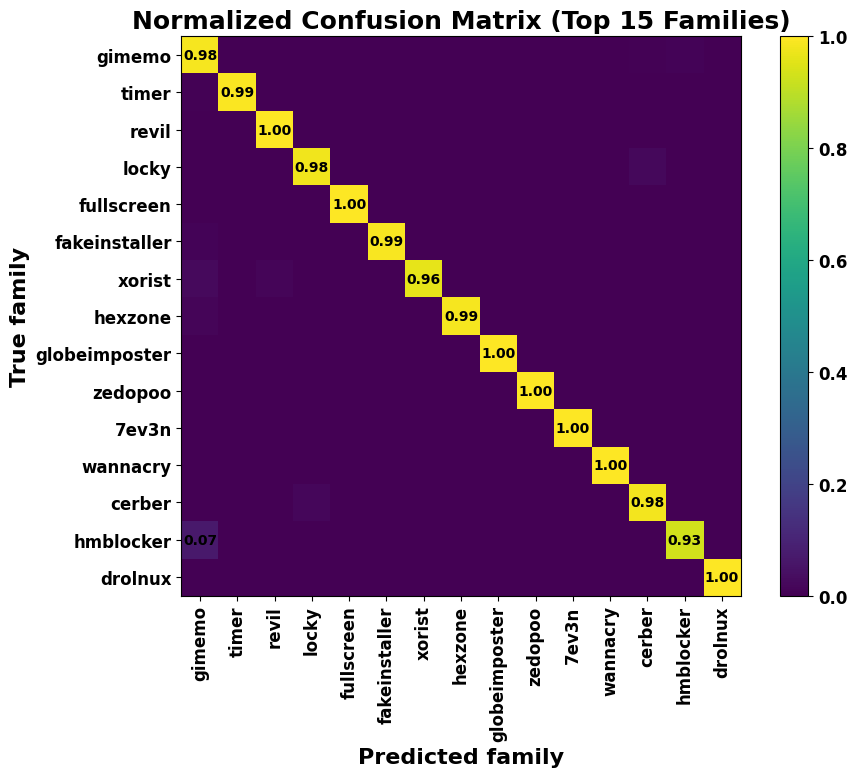

Saved Figure A: outputs/FigA_confusion_top15_norm_all_labels.png and outputs/FigA_confusion_top15_norm_all_labels.pdf


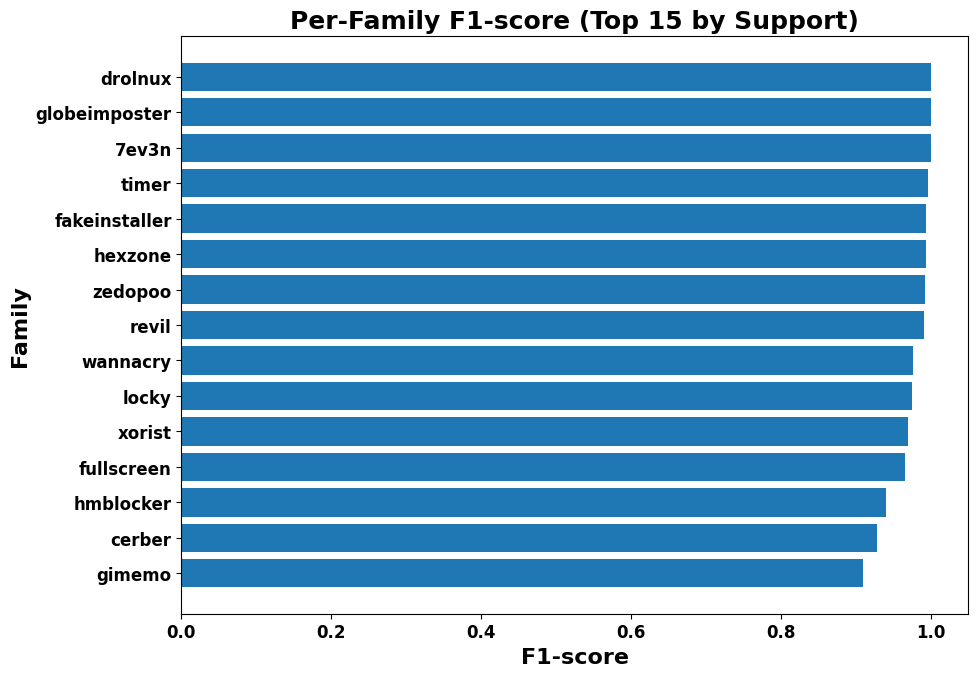

Saved Figure B: outputs/FigB_f1_top15_support_all_labels.png and outputs/FigB_f1_top15_support_all_labels.pdf


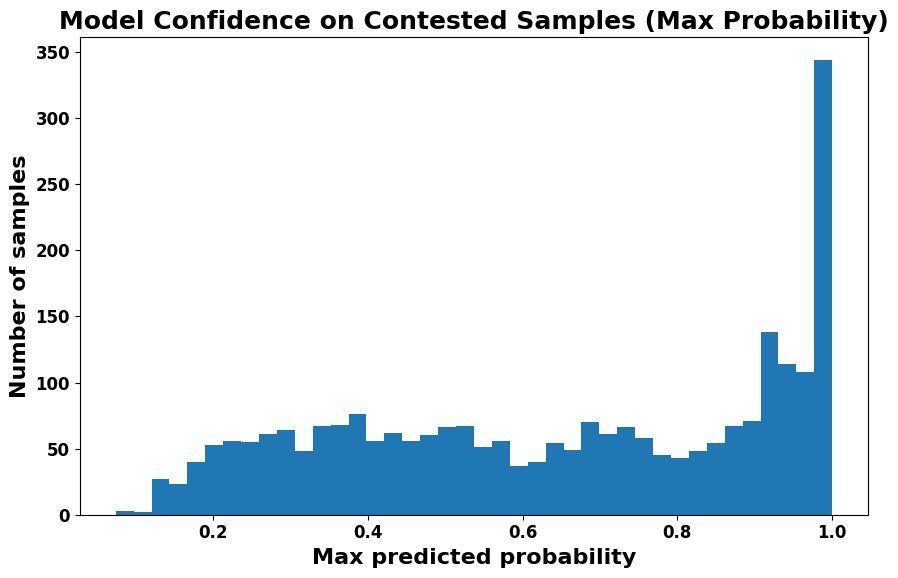

Saved Figure C: outputs/FigC_confidence_hist_contested_all_labels.png and outputs/FigC_confidence_hist_contested_all_labels.pdf

Contested confidence summary:
count    2584.000000
mean        0.645330
std         0.272220
min         0.074242
5%          0.203677
10%         0.259420
25%         0.399073
50%         0.673786
75%         0.920030
90%         0.990274
95%         0.998093
max         0.999948
dtype: float64


In [14]:
# Cell — Figures A/B/C for the paper (Top-15 Confusion, Top-15 F1, Contested Confidence)
# Best model: XGBoost (xgb)
# Saves PNG + PDF into OUT_DIR

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import train_test_split


# ----------------- GLOBAL PLOT SETTINGS -----------------
plt.rcParams.update({
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "figure.titleweight": "bold",
    
    # Note the commas at the end of every line below:
    "font.size": 14,          # Global default size
    "axes.titlesize": 18,     # Main title size
    "axes.labelsize": 16,     # X and Y axis label size
    "xtick.labelsize": 12,    # X-axis tick label size
    "ytick.labelsize": 12     # Y-axis tick label size
})

# ----------------- Sanity checks -----------------
required = ["xgb", "X_va", "y_va", "le", "meta_va", "X_unres_final", "unres_sha", "OUT_DIR", "RUN_TAG"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Missing variables in notebook: {missing}\n"
                     f"Expected you have them from previous cells. If you lost X_va/y_va/meta_va, rerun the split cell.")

# Ensure arrays
X_va_arr = np.asarray(X_va)
y_va_arr = np.asarray(y_va).astype(int)

# Make sure the model is fit (if already fit, this is harmless check)
if not hasattr(xgb, "classes_"):
    raise ValueError("xgb does not look fitted. Run your training cell first.")

# Predictions + probabilities on validation
pred_va = np.asarray(xgb.predict(X_va_arr)).astype(int)
P_va = np.asarray(xgb.predict_proba(X_va_arr))

# ----------------- Helper: top-k classes by support in y_va -----------------
def topk_by_support(y_true, k=15):
    counts = np.bincount(y_true, minlength=len(le.classes_))
    top_idx = np.argsort(counts)[::-1][:k]
    top_idx = [i for i in top_idx if counts[i] > 0]
    return top_idx, counts

top_idx, counts = topk_by_support(y_va_arr, k=15)
top_names = le.inverse_transform(np.array(top_idx))

# ----------------- Figure A: Normalized confusion matrix (Top-15) -----------------
# Build confusion matrix only for top classes (filter rows with true in top_idx)
mask_top_true = np.isin(y_va_arr, top_idx)
y_true_top = y_va_arr[mask_top_true]
y_pred_top = pred_va[mask_top_true]

# Map global class indices -> 0..K-1
map_to_local = {c:i for i,c in enumerate(top_idx)}
y_true_local = np.array([map_to_local[t] for t in y_true_top], dtype=int)

# For predictions: if predicted class not in top list, map to "other" by dropping those counts.
# We keep only predictions that land inside top list; others are ignored in per-row normalization.
y_pred_local = []
for p in y_pred_top:
    if p in map_to_local:
        y_pred_local.append(map_to_local[p])
    else:
        y_pred_local.append(-1)
y_pred_local = np.array(y_pred_local, dtype=int)

# Confusion matrix (KxK) counting only pred in top list
K = len(top_idx)
cm = np.zeros((K, K), dtype=np.int64)
for t, p in zip(y_true_local, y_pred_local):
    if p >= 0:
        cm[t, p] += 1

# Row-normalize (recall normalization)
cm_norm = cm.astype(np.float64)
row_sums = cm_norm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_norm, row_sums, out=np.zeros_like(cm_norm), where=row_sums != 0)

figA_path_png = OUT_DIR / f"FigA_confusion_top15_norm_{RUN_TAG}.png"
figA_path_pdf = OUT_DIR / f"FigA_confusion_top15_norm_{RUN_TAG}.pdf"

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("Normalized Confusion Matrix (Top 15 Families)")
plt.colorbar()
tick_marks = np.arange(K)
plt.xticks(tick_marks, top_names, rotation=90)
plt.yticks(tick_marks, top_names)

# annotate values
diag_fs = 10          # <-- only diagonal (yellow squares)
offdiag_fs = 10    # keep others unchanged (uses rcParams)

for i in range(K):
    for j in range(K):
        val = cm_norm[i, j]

        # keep your original rule for showing annotations
        if val >= 0.05:
            fs = diag_fs if i == j else offdiag_fs
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=fs)


# # annotate values
# for i in range(K):
#     for j in range(K):
#         val = cm_norm[i, j]
#         if val >= 0.05:  # annotate only meaningful cells
#             plt.text(j, i, f"{val:.2f}", ha="center", va="center")

plt.ylabel("True family")
plt.xlabel("Predicted family")
plt.tight_layout()
plt.savefig(figA_path_png, dpi=300, bbox_inches="tight")
plt.savefig(figA_path_pdf, bbox_inches="tight")
plt.show()

print("Saved Figure A:", figA_path_png, "and", figA_path_pdf)

# ----------------- Figure B: Per-family F1-score (Top-15 by support) -----------------
# Compute per-class F1 for all classes, then take top-15 by support
f1_all = f1_score(y_va_arr, pred_va, average=None, labels=np.arange(len(le.classes_)))
support_all = counts  # from bincount above (y_va distribution)

df_f1 = pd.DataFrame({
    "family": le.classes_,
    "support": support_all,
    "f1": f1_all
})
df_f1_top = df_f1.sort_values("support", ascending=False).head(15).copy()
df_f1_top = df_f1_top.sort_values("f1", ascending=True)  # for nicer horizontal bars

figB_path_png = OUT_DIR / f"FigB_f1_top15_support_{RUN_TAG}.png"
figB_path_pdf = OUT_DIR / f"FigB_f1_top15_support_{RUN_TAG}.pdf"

plt.figure(figsize=(10, 7))
plt.barh(df_f1_top["family"], df_f1_top["f1"])
plt.title("Per-Family F1-score (Top 15 by Support)")
plt.xlabel("F1-score")
plt.ylabel("Family")
plt.tight_layout()
plt.savefig(figB_path_png, dpi=300, bbox_inches="tight")
plt.savefig(figB_path_pdf, bbox_inches="tight")
plt.show()

print("Saved Figure B:", figB_path_png, "and", figB_path_pdf)

# ----------------- Figure C: Confidence histogram on contested predictions -----------------
# contested = unresolved in your pipeline
P_unres = np.asarray(xgb.predict_proba(np.asarray(X_unres_final)))
conf_unres = P_unres.max(axis=1)

figC_path_png = OUT_DIR / f"FigC_confidence_hist_contested_{RUN_TAG}.png"
figC_path_pdf = OUT_DIR / f"FigC_confidence_hist_contested_{RUN_TAG}.pdf"

plt.figure(figsize=(9, 6))
plt.hist(conf_unres, bins=40)
plt.title("Model Confidence on Contested Samples (Max Probability)")
plt.xlabel("Max predicted probability")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.savefig(figC_path_png, dpi=300, bbox_inches="tight")
plt.savefig(figC_path_pdf, bbox_inches="tight")
plt.show()

print("Saved Figure C:", figC_path_png, "and", figC_path_pdf)

# ----------------- Quick summary stats for paper text -----------------
print("\nContested confidence summary:")
print(pd.Series(conf_unres).describe(percentiles=[0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]))
